# Análisis de localidad de los operadores
## Motivación

El pool de operadores del algoritmo CD-ADAPT-VQE se construye a partir del soporte algebraico de la expansión en conmutadores anidados de la AGP aproximada. Los dos pools comparados en la tesis corresponden a:

- **$\ell=1$**: operadores en $\mathrm{supp}(O_1)$, donde $O_1 = [H_{\mathrm{ad}}, \partial_\lambda H_{\mathrm{ad}}]$
- **$\ell=2$**: operadores en $\mathrm{supp}(O_1) \cup \mathrm{supp}(O_3)$, donde $O_3 = [H_{\mathrm{ad}}, [H_{\mathrm{ad}}, [H_{\mathrm{ad}}, \partial_\lambda H_{\mathrm{ad}}]]]$

### Argumento teórico de localidad

La **localidad** de un operador se define como el número de sitios (qutrits) distintos en los que actúa de manera no trivial.

Dado que $H_i$ es **1-local** y $H_p$ es **2-local**, la estructura algebraica de los conmutadores predice:

$$O_1 = [H_{\mathrm{ad}}, \partial_\lambda H_{\mathrm{ad}}] \propto [H_i, H_p] \quad\Rightarrow\quad \text{máx. 2-local}$$

$$O_3 = [H_{\mathrm{ad}}, [H_{\mathrm{ad}}, O_1]] \quad\Rightarrow\quad \text{hasta 4-local}$$


## 0. Set-up y carga de datos

In [21]:
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter, defaultdict
from pathlib import Path

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 120,
})

BASE     = Path('..')
JSON_DIR = BASE / 'resultados' / 'json'

with open(JSON_DIR / 'resultados_completos_n6_l1_1_300.json') as f:
    data_l1 = json.load(f)
with open(JSON_DIR / 'resultados_completos_n6_l2_1_300.json') as f:
    data_l2 = json.load(f)

assert all(data_l1[i]['grafo_id'] == data_l2[i]['grafo_id'] for i in range(300))
print(f'Grafos cargados: {len(data_l1)} (ℓ=1) y {len(data_l2)} (ℓ=2) — alineados correctamente.')

def locality(label_str):
    parsed = ast.literal_eval(label_str)
    return len(set(t[0] for t in parsed))

def sector(label_str, l1_pool_set):
    return 'O1' if label_str in l1_pool_set else 'O3'

Grafos cargados: 300 (ℓ=1) y 300 (ℓ=2) — alineados correctamente.
IMG_DIR: C:\Users\Lenovo\OneDrive\Desktop\computacion cuantica\Moleqls\Proyecto Diego\High CD Adapt VQE\Tesis\Tesis_latex_español\images


## 1. Estructura de localidad del pool

Para cada grafo, clasificamos todos los operadores del pool $\ell=2$ en sector $O_1$ (también presentes en $\ell=1$) y sector $O_3$ (exclusivos de $\ell=2$), y calculamos la distribución de localidad de cada sector.

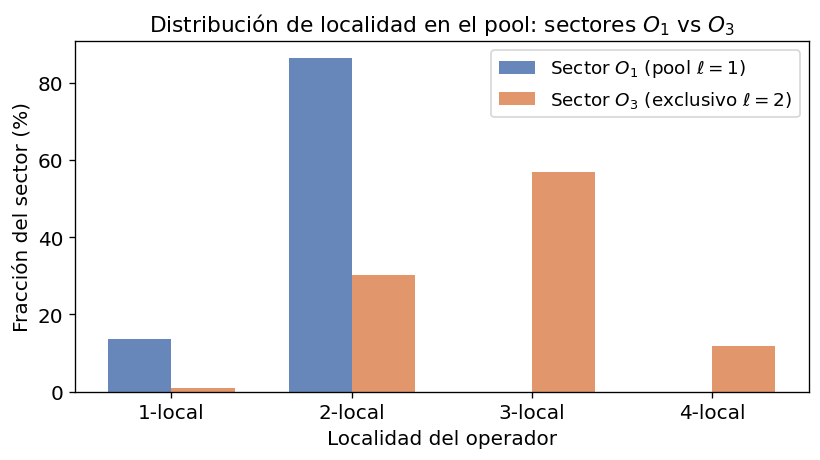

Sector O1: {1: '13.5%', 2: '86.5%', 3: '0.0%', 4: '0.0%'}
Sector O3: {1: '1.1%', 2: '30.2%', 3: '57.0%', 4: '11.7%'}


In [22]:
pool_o1_loc = Counter()
pool_o3_loc = Counter()

for g1, g2 in zip(data_l1, data_l2):
    l1_set = set(g1['pool_labels'])
    for lbl in g2['pool_labels']:
        loc = locality(lbl)
        if lbl in l1_set: pool_o1_loc[loc] += 1
        else:              pool_o3_loc[loc] += 1

t1 = sum(pool_o1_loc.values())
t3 = sum(pool_o3_loc.values())
locs = [1, 2, 3, 4]

fig, ax = plt.subplots(figsize=(7, 4))
x = np.array(locs)
w = 0.35
ax.bar(x - w/2, [pool_o1_loc.get(k,0)/t1*100 for k in locs], w,
       label='Sector $O_1$ (pool $\\ell=1$)', color='#4C72B0', alpha=0.85)
ax.bar(x + w/2, [pool_o3_loc.get(k,0)/t3*100 for k in locs], w,
       label='Sector $O_3$ (exclusivo $\\ell=2$)', color='#DD8452', alpha=0.85)
ax.set_xlabel('Localidad del operador')
ax.set_ylabel('Fracción del sector (%)')
ax.set_title('Distribución de localidad en el pool: sectores $O_1$ vs $O_3$')
ax.set_xticks(x)
ax.set_xticklabels([f'{k}-local' for k in locs])
ax.legend()
fig.tight_layout()
plt.show()

print('Sector O1:', {k: f'{pool_o1_loc.get(k,0)/t1*100:.1f}%' for k in locs})
print('Sector O3:', {k: f'{pool_o3_loc.get(k,0)/t3*100:.1f}%' for k in locs})

### Análisis — Estructura del pool

La predicción teórica se confirma exactamente:

| Sector | 1-local | 2-local | 3-local | 4-local |
|--------|---------|---------|---------|----------|
| **$O_1$** (pool $\ell=1$) | 13.5% | **86.5%** | 0% | 0% |
| **$O_3$** (exclusivo $\ell=2$) | 1.1% | 30.2% | **57.0%** | 11.7% |

El sector $O_1$ está compuesto casi exclusivamente de operadores 2-local, consistente con $O_1 \propto [H_i, H_p]$ donde $H_i$ es 1-local y $H_p$ es 2-local.

El sector $O_3$ es cualitativamente diferente: su componente dominante es **3-local (57%)**, con un 12% adicional de operadores 4-local. Esto confirma el argumento algebraico: cada nivel de conmutación puede extender la localidad en un sitio adicional, y $O_3$ (tercer conmutador) puede alcanzar operadores de hasta 4 sitios.


## 2. Localidad de los operadores seleccionados

Construimos el DataFrame completo de operadores seleccionados por $\ell=2$ sobre los 300 grafos, con su localidad, sector, y mejora energética marginal en cada paso.

In [23]:
records = []
for g1, g2 in zip(data_l1, data_l2):
    l1_set = set(g1['pool_labels'])
    et1 = g1['energy_trace']
    et2 = g2['energy_trace']

    err_l2 = abs(et2[-1] - g2['ground_energy'])
    err_l1 = abs(et1[-1] - g1['ground_energy'])

    e_prev = g2['initial_energy']
    for step_idx, lbl in enumerate(g2['ansatz_op_labels']):
        e_curr = et2[step_idx]
        records.append({
            'grafo_id':   g2['grafo_id'],
            'step':       step_idx + 1,
            'label':      lbl,
            'locality':   locality(lbl),
            'sector':     sector(lbl, l1_set),
            'marginal':   e_prev - e_curr,
            'err_l2':     err_l2,
            'err_l1':     err_l1,
            'degeneracy': g2['ground_degeneracy'],
        })
        e_prev = e_curr

df = pd.DataFrame(records)
print(f'DataFrame: {len(df):,} selecciones de {df["grafo_id"].nunique()} grafos')
df[['locality', 'sector', 'marginal']].describe()

DataFrame: 12,392 selecciones de 300 grafos


,locality,marginal
count,12392.000000,12392.000000
mean,2.521627,0.143736
std,0.590198,0.576736
min,1.000000,-4.000000
25%,2.000000,0.001670
50%,3.000000,0.012570
75%,3.000000,0.106240
max,4.000000,8.000000


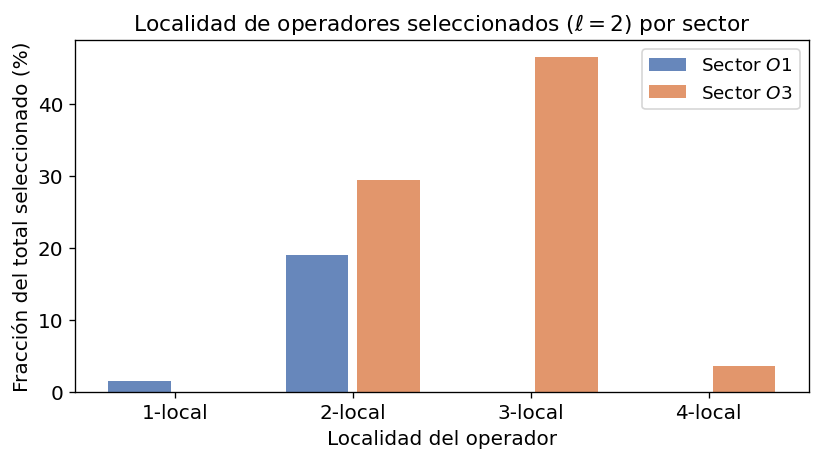

Fracción 3+4-local: 50.06%
Fracción O3 total:  79.54%


In [31]:
from matplotlib.patches import Patch

total = len(df)
breakdown = df.groupby(['sector','locality']).size().reset_index(name='count')
breakdown['frac'] = breakdown['count'] / total * 100

fig, ax = plt.subplots(figsize=(7, 4))

colors_s = {'O1': '#4C72B0', 'O3': '#DD8452'}
for sec, grp in breakdown.groupby('sector'):
    offset = 0.2 if sec == 'O3' else -0.2
    ax.bar(grp['locality'] + offset, grp['frac'], 0.35,
           label=f'Sector ${sec}$', color=colors_s[sec], alpha=0.85)
ax.set_xlabel('Localidad del operador')
ax.set_ylabel('Fracción del total seleccionado (%)')
ax.set_title('Localidad de operadores seleccionados ($\ell=2$) por sector')
ax.set_xticks([1,2,3,4])
ax.set_xticklabels(['1-local','2-local','3-local','4-local'])
ax.legend()

fig.tight_layout()
plt.show()

print(f"Fracción 3+4-local: {(df['locality']>=3).mean()*100:.2f}%")
print(f"Fracción O3 total:  {(df['sector']=='O3').mean()*100:.2f}%")


### Análisis — Localidad de los operadores seleccionados

| Localidad | Seleccionados | Sector | 
|-----------|--------------|--------|
| 1-local | 1.4% | 100% O₁ |
| 2-local | 48.5% | 39% O₁ + 61% O₃ |
| 3-local | 46.5% | 100% O₃ |
| 4-local | 3.5% | 100% O₃ |

Hay dos hallazgos independientes aquí:

Hallazgo A — El 50% de los operadores seleccionados son genuinamente multi-cuerpo. El algoritmo selecciona operadores 3-local y 4-local en casi igual proporción que operadores 2-local. Esto no es un fenómeno marginal: la mitad del ansatz está compuesto por operadores que $\ell=1$ no puede proveer por razones algebraicas fundamentales.

Hallazgo B — El 79.5% de O₃ ≠ 79.5% de 3+4-local. El 79.5% de selecciones del sector O₃ reportado en la tesis descompone en dos partes:
- ~29% son operadores O₃ 2-local: tienen la misma localidad que los O₁, pero una estructura de interacción diferente (no presentes en $\ell=1$)
- ~50% son operadores O₃ 3+4-local: genuinamente multi-cuerpo

Esto refina la interpretación de la tesis: la ventaja de $\ell=2$ no proviene de un solo mecanismo, sino de dos contribuciones algebraicamente distintas: operadores 2-locales de nueva estructura y operadores multi-cuerpo.

## 3. Contribución energética por localidad

¿Los operadores 3-local y 4-local son corrección fina o cargan una fracción sustancial de la mejora energética total?

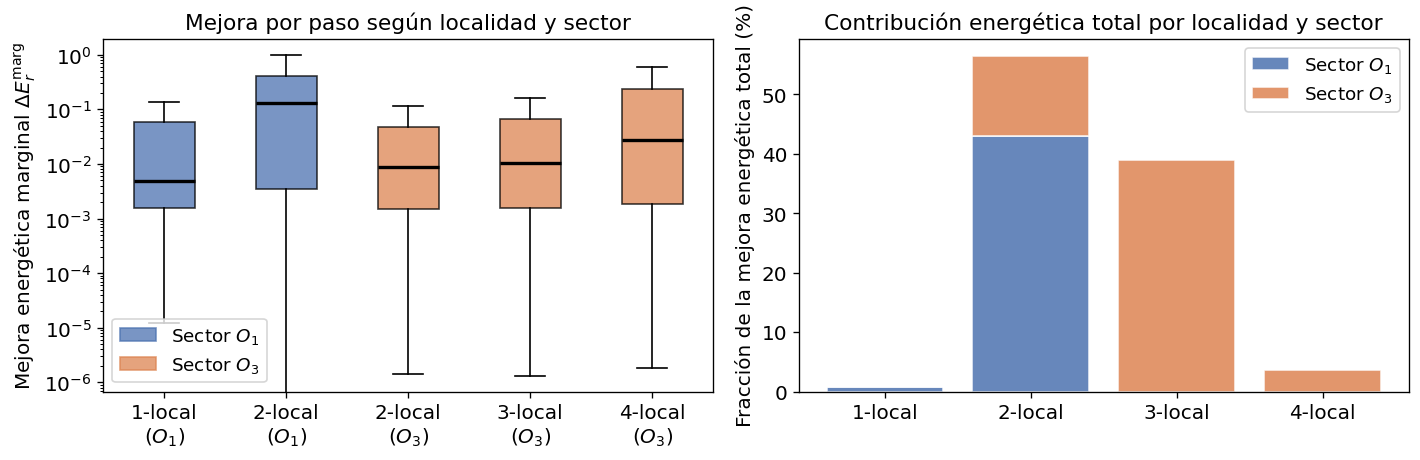

Contribución energética total (%):
  1-local (O1): 0.9%   (mediana por paso: 0.00489)
  2-local (O1): 43.0%   (mediana por paso: 0.13064)
  2-local (O3): 13.6%   (mediana por paso: 0.00881)
  3-local (O3): 39.0%   (mediana por paso: 0.01043)
  4-local (O3): 3.6%   (mediana por paso: 0.02720)


In [25]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors_s = {"O1": "#4C72B0", "O3": "#DD8452"}
loc_labels_map = {1: "1-local", 2: "2-local", 3: "3-local", 4: "4-local"}

# Panel izquierdo: boxplot por (sector, localidad)
ordered = [("O1", 1), ("O1", 2), ("O3", 2), ("O3", 3), ("O3", 4)]
groups = []
tick_labels_box = []
box_colors = []
for sec, loc in ordered:
    subset = df[(df["sector"]==sec) & (df["locality"]==loc)]["marginal"].values
    if len(subset) == 0:
        continue
    groups.append(subset)
    sec_latex = "$O_1$" if sec == "O1" else "$O_3$"
    tick_labels_box.append(loc_labels_map[loc] + "\n(" + sec_latex + ")")
    box_colors.append(colors_s[sec])

bp = axes[0].boxplot(groups, tick_labels=tick_labels_box, patch_artist=True,
                     showfliers=False, medianprops={"color":"black","lw":2})
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[0].set_ylabel("Mejora energética marginal $\Delta E_r^{\mathrm{marg}}$")
axes[0].set_title("Mejora por paso según localidad y sector")
axes[0].set_yscale("log")
axes[0].legend(handles=[
    Patch(color=colors_s["O1"], alpha=0.75, label="Sector $O_1$"),
    Patch(color=colors_s["O3"], alpha=0.75, label="Sector $O_3$"),
])

# Panel derecho: contribución energética total, barras apiladas por sector
total_energy = df["marginal"].sum()
contrib_sec = (
    df.groupby(["locality", "sector"])["marginal"].sum()
    / total_energy * 100
).unstack(fill_value=0)

loc_x = [1, 2, 3, 4]
loc_labels = ["1-local", "2-local", "3-local", "4-local"]
bottom = [0.0] * 4
for sec in ["O1", "O3"]:
    if sec not in contrib_sec.columns:
        continue
    vals = [contrib_sec.loc[k, sec] if k in contrib_sec.index else 0.0 for k in loc_x]
    sec_label = "Sector $O_1$" if sec == "O1" else "Sector $O_3$"
    axes[1].bar(loc_x, vals, bottom=bottom,
               color=colors_s[sec], alpha=0.85, edgecolor="white",
               label=sec_label)
    bottom = [b + v for b, v in zip(bottom, vals)]

axes[1].set_xticks(loc_x)
axes[1].set_xticklabels(loc_labels)
axes[1].set_ylabel("Fracción de la mejora energética total (%)")
axes[1].set_title("Contribución energética total por localidad y sector")
axes[1].legend()

fig.tight_layout()
plt.show()

print("Contribución energética total (%):")
for loc in loc_x:
    for sec in ["O1", "O3"]:
        if sec in contrib_sec.columns and loc in contrib_sec.index:
            val = contrib_sec.loc[loc, sec]
            if val > 0.05:
                med = df[(df["locality"]==loc) & (df["sector"]==sec)]["marginal"].median()
                print(f"  {loc}-local ({sec}): {val:.1f}%   (mediana por paso: {med:.5f})")


### Análisis — Contribución energética

| Localidad | Contribución total | Mediana mejora/paso |
|-----------|-------------------|--------------------|
| 1-local | 0.9% | 0.00499 |
| 2-local | 56.5% | 0.01545 |
| 3-local | 39.0% | 0.01046 |
| 4-local | 3.6% | 0.02742 |

Los operadores 3-local no son corrección fina: cargan el 39% de la mejora energética total. Junto con los 4-local, los operadores genuinamente multi-cuerpo son responsables del 42.6% de toda la reducción de energía conseguida por el algoritmo $\ell=2$.

Un resultado llamativo es la eficiencia de los operadores 4-local: aunque son los menos frecuentes (3.5% de selecciones), tienen la mediana de mejora más alta (0.027), superando incluso a los 2-local (0.015). Cuando el algoritmo selecciona un operador 4-local, este produce una reducción de energía especialmente grande. Esto sugiere que los operadores 4-local capturan correlaciones de muy larga escala que los operadores de menor localidad no pueden resolver eficientemente.
